In [105]:
from python_files.JPEGCompression import blockProcessing
from matplotlib import pyplot as plt
import cv2 as cv
import numpy as np

COMPRESSION_PER = 30.0
img_BGR = cv.imread("Aula_2_files/usb_32x32.png")
img_BGR = cv.cvtColor(img_BGR, cv.COLOR_BGR2RGB)

Ex 2

2.1

In [106]:
img_YCrCb = cv.cvtColor(img_BGR, cv.COLOR_BGR2YCrCb)
imgChannelY, imgChannelCr, imgChannelCb  = cv.split(img_YCrCb)

2.2

In [107]:
imgChannelCb = cv.resize(imgChannelCb, None, fx=0.5, fy=1, interpolation=cv.INTER_AREA)
imgChannelCr = cv.resize(imgChannelCr, None, fx=0.5, fy=1, interpolation=cv.INTER_AREA)

2.3

In [108]:
BLOCK_SIZE = 8

height, width = imgChannelY.shape
N_width_blocks = int(width/ BLOCK_SIZE)
N_height_blocks = int(height/ BLOCK_SIZE)
reconstructedY = np.zeros_like(imgChannelY)
for i in range(N_height_blocks):
    for j in range(N_width_blocks):
        imgChannelBlock = imgChannelY[i*BLOCK_SIZE : i*BLOCK_SIZE+BLOCK_SIZE, j*BLOCK_SIZE : j*BLOCK_SIZE+BLOCK_SIZE]
        resultBlock = blockProcessing(imgChannelBlock,1, COMPRESSION_PER)
        reconstructedY[i*BLOCK_SIZE : (i+1)*BLOCK_SIZE, j*BLOCK_SIZE : (j+1)*BLOCK_SIZE] = resultBlock

height, width = imgChannelCb.shape
N_width_blocks = int(width/ BLOCK_SIZE)
N_height_blocks = int(height/ BLOCK_SIZE)
reconstructedCb = np.zeros_like(imgChannelCb)
for i in range(N_height_blocks):
    for j in range(N_width_blocks):
        imgChannelBlock = imgChannelCb[i*BLOCK_SIZE : i*BLOCK_SIZE+BLOCK_SIZE, j*BLOCK_SIZE : j*BLOCK_SIZE+BLOCK_SIZE]
        resultBlock = blockProcessing(imgChannelBlock,0, COMPRESSION_PER)
        reconstructedCb[i*BLOCK_SIZE : (i+1)*BLOCK_SIZE, j*BLOCK_SIZE : (j+1)*BLOCK_SIZE] = resultBlock

height, width = imgChannelCr.shape
N_width_blocks = int(width/ BLOCK_SIZE)
N_height_blocks = int(height/ BLOCK_SIZE)
reconstructedCr = np.zeros_like(imgChannelCr)
for i in range(N_height_blocks):
    for j in range(N_width_blocks):
        imgChannelBlock = imgChannelCr[i*BLOCK_SIZE : i*BLOCK_SIZE+BLOCK_SIZE, j*BLOCK_SIZE : j*BLOCK_SIZE+BLOCK_SIZE]
        resultBlock = blockProcessing(imgChannelBlock,0, COMPRESSION_PER)
        reconstructedCr[i*BLOCK_SIZE : (i+1)*BLOCK_SIZE, j*BLOCK_SIZE : (j+1)*BLOCK_SIZE] = resultBlock

2.4

In [109]:
reconstructedCb = cv.resize(reconstructedCb ,None,fx=2, fy=1, interpolation=cv.INTER_AREA )
reconstructedCr = cv.resize(reconstructedCr ,None,fx=2, fy=1, interpolation=cv.INTER_AREA )

2.5

In [110]:
img_JPEG = cv.merge((reconstructedY, reconstructedCr, reconstructedCb))
img_JPEG = cv.cvtColor(img_JPEG, cv.COLOR_YCrCb2BGR)

Display images

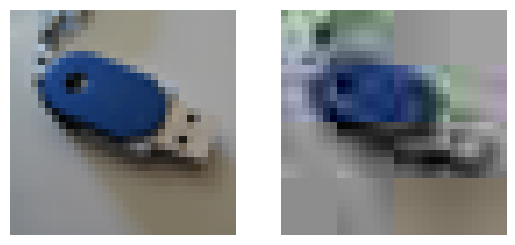

In [111]:
plt.figure()
plt.subplot(1,2,1)
plt.imshow(img_BGR)
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(img_JPEG)
plt.axis('off')
plt.show()